# SFT Telemetry Decision Notebook

Цель: быстро понять, какие `label/source` усиливать в `dense` dataset, а какие резать.

Порядок:
1. load train/eval analysis reports;
2. compare labels and source+label;
3. inspect bad tokens and hard examples;
4. get suggested `label_weights`;
5. copy dense builder command.


In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 240)
pd.set_option("display.width", 240)


## 1. Paths

In [4]:
MODEL_DIR = Path("../models/sft_v0.0.13")
TRAIN_CSV = Path("../data/generated/train_with_syntetic.csv")
VAL_CSV = Path("../data/prepared/val_stratified.csv")

TRAIN_ANALYSIS_DIR = Path(str(MODEL_DIR) + "_train_telemetry_analysis")
EVAL_ANALYSIS_DIR = Path(str(MODEL_DIR) + "_eval_telemetry_analysis")

# fallback for old one-folder analysis
if not TRAIN_ANALYSIS_DIR.exists():
    fallback = Path(str(MODEL_DIR) + "_telemetry_analysis")
    if fallback.exists():
        TRAIN_ANALYSIS_DIR = fallback

print("MODEL_DIR:", MODEL_DIR)
print("TRAIN_ANALYSIS_DIR:", TRAIN_ANALYSIS_DIR, "exists=", TRAIN_ANALYSIS_DIR.exists())
print("EVAL_ANALYSIS_DIR:", EVAL_ANALYSIS_DIR, "exists=", EVAL_ANALYSIS_DIR.exists())
print("TRAIN_CSV:", TRAIN_CSV, "exists=", TRAIN_CSV.exists())
print("VAL_CSV:", VAL_CSV, "exists=", VAL_CSV.exists())


MODEL_DIR: ../models/sft_v0.0.13
TRAIN_ANALYSIS_DIR: ../models/sft_v0.0.13_telemetry_analysis exists= True
EVAL_ANALYSIS_DIR: ../models/sft_v0.0.13_eval_telemetry_analysis exists= False
TRAIN_CSV: ../data/generated/train_with_syntetic.csv exists= True
VAL_CSV: ../data/prepared/val_stratified.csv exists= True


## 2. Load reports

In [5]:
def read_csv_if_exists(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    print("Missing:", path)
    return pd.DataFrame()

def read_json_if_exists(path: Path) -> dict:
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    print("Missing:", path)
    return {}

def load_analysis(analysis_dir: Path) -> dict:
    return {
        "summary": read_json_if_exists(analysis_dir / "00_input_summary.json"),
        "by_label": read_csv_if_exists(analysis_dir / "01_by_label.csv"),
        "by_source_label": read_csv_if_exists(analysis_dir / "02_by_source_label.csv"),
        "hard_examples": read_csv_if_exists(analysis_dir / "03_hard_examples.csv"),
        "bad_tokens": read_csv_if_exists(analysis_dir / "04_bad_tokens.csv"),
    }

train = load_analysis(TRAIN_ANALYSIS_DIR)
eval_ = load_analysis(EVAL_ANALYSIS_DIR)

train_df = pd.read_csv(TRAIN_CSV) if TRAIN_CSV.exists() else pd.DataFrame()
val_df = pd.read_csv(VAL_CSV) if VAL_CSV.exists() else pd.DataFrame()

print("train by_label rows:", len(train["by_label"]))
print("eval by_label rows:", len(eval_["by_label"]))
print("train rows:", len(train_df))
print("val rows:", len(val_df))


Missing: ../models/sft_v0.0.13_eval_telemetry_analysis/00_input_summary.json
Missing: ../models/sft_v0.0.13_eval_telemetry_analysis/01_by_label.csv
Missing: ../models/sft_v0.0.13_eval_telemetry_analysis/02_by_source_label.csv
Missing: ../models/sft_v0.0.13_eval_telemetry_analysis/03_hard_examples.csv
Missing: ../models/sft_v0.0.13_eval_telemetry_analysis/04_bad_tokens.csv
train by_label rows: 6
eval by_label rows: 0
train rows: 11029
val rows: 950


## 3. Sanity check

In [6]:
print("TRAIN SUMMARY")
display(pd.DataFrame([train["summary"]]))

print("EVAL SUMMARY")
display(pd.DataFrame([eval_["summary"]]))


TRAIN SUMMARY


,telemetry_files_count,telemetry_files,raw_records_count,latest_records_count,unique_ids_raw,unique_ids_latest,unknown_source_count,unknown_label_count,zero_loss_tokens_count,checkpoint_buckets
0,7,"[models/sft_v0.0.13/train_telemetry/train_until_checkpoint-100_rank-0.jsonl, models/sft_v0.0.13/train_telemetry/train_until_checkpoint-150_rank-0.jsonl, models/sft_v0.0.13/train_telemetry/train_until_checkpoint-200_rank-0.jsonl, models/...",10184,10184,10184,10184,0,0,0,"[50, 100, 150, 200, 250, 300, 350]"


EVAL SUMMARY


""
0


Ожидаемо:
- `unknown_source_count == 0`;
- `unknown_label_count == 0`;
- `zero_loss_tokens_count == 0`;
- train/eval имеют ожидаемые checkpoint buckets.


## 4. Train vs Eval by label

In [7]:
def prepare_by_label(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    keep = [
        "label", "count", "unique_ids", "difficulty_score",
        "mean_nll", "p50_mean_nll", "p95_mean_nll",
        "hard_token_ratio", "near_zero_token_ratio",
        "cot_mean_nll", "final_answer_mean_nll", "boxed_answer_mean_nll", "format_mean_nll",
        "answer_score", "cot_score", "format_score",
        "hard_examples_ratio", "very_hard_examples_ratio", "easy_examples_ratio",
    ]
    keep = [c for c in keep if c in df.columns]

    out = df[keep].copy()
    out = out.rename(columns={c: f"{prefix}_{c}" for c in out.columns if c != "label"})
    return out

train_label = prepare_by_label(train["by_label"], "train")
eval_label = prepare_by_label(eval_["by_label"], "eval")

if not train_label.empty and not eval_label.empty:
    label_cmp = train_label.merge(eval_label, on="label", how="outer")
elif not train_label.empty:
    label_cmp = train_label.copy()
else:
    label_cmp = eval_label.copy()

if not label_cmp.empty:
    label_cmp["decision_score"] = (
        label_cmp.get("eval_difficulty_score", 0).fillna(0) * 2.0
        + label_cmp.get("eval_hard_examples_ratio", 0).fillna(0) * 1.5
        + label_cmp.get("eval_boxed_answer_mean_nll", 0).fillna(0) * 2.0
        + label_cmp.get("train_difficulty_score", 0).fillna(0) * 1.0
    )
    label_cmp = label_cmp.sort_values("decision_score", ascending=False)

display(label_cmp)


AttributeError: 'int' object has no attribute 'fillna'

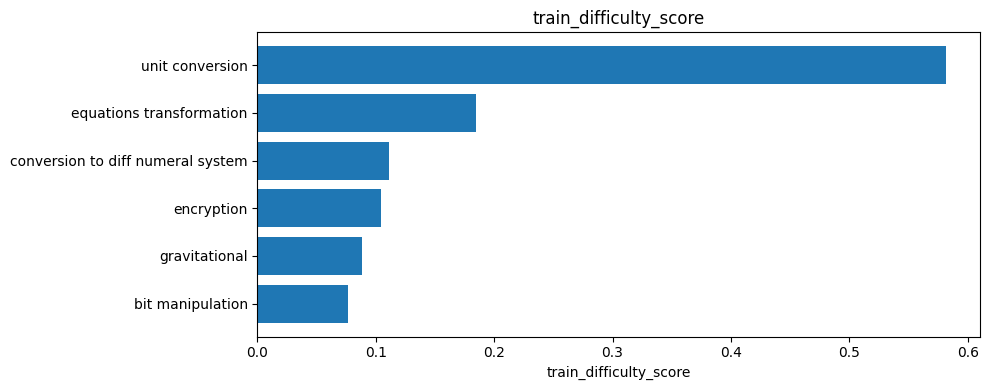

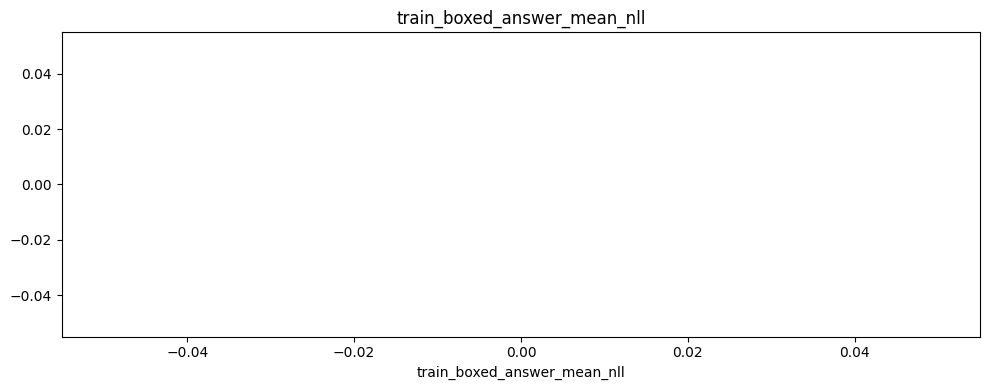

In [8]:
if not label_cmp.empty:
    for col in ["train_difficulty_score", "eval_difficulty_score", "train_boxed_answer_mean_nll", "eval_boxed_answer_mean_nll"]:
        if col not in label_cmp.columns:
            continue
        plot_df = label_cmp[["label", col]].dropna().sort_values(col, ascending=True)
        plt.figure(figsize=(10, max(4, len(plot_df) * 0.45)))
        plt.barh(plot_df["label"], plot_df[col])
        plt.title(col)
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()


Как читать:
- `eval_difficulty_score` высокий → unseen задачи плохо обобщаются;
- `train_difficulty_score` высокий, eval низкий → может быть CoT/format/verbatim сложность;
- `eval_boxed_answer_mean_nll` высокий → модель плохо предсказывает именно ответ;
- `easy_examples_ratio` высокий → можно downsample.


## 5. Source + label

In [9]:
def prepare_by_source_label(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    keep = [
        "source", "label", "count", "unique_ids", "difficulty_score",
        "mean_nll", "p95_mean_nll", "hard_token_ratio", "near_zero_token_ratio",
        "cot_mean_nll", "boxed_answer_mean_nll", "format_mean_nll",
        "answer_score", "cot_score", "format_score",
        "hard_examples_ratio", "very_hard_examples_ratio", "easy_examples_ratio",
    ]
    keep = [c for c in keep if c in df.columns]

    out = df[keep].copy()
    out = out.rename(columns={c: f"{prefix}_{c}" for c in out.columns if c not in ["source", "label"]})
    return out

train_sl = prepare_by_source_label(train["by_source_label"], "train")
eval_sl = prepare_by_source_label(eval_["by_source_label"], "eval")

if not train_sl.empty and not eval_sl.empty:
    sl_cmp = train_sl.merge(eval_sl, on=["source", "label"], how="outer")
elif not train_sl.empty:
    sl_cmp = train_sl.copy()
else:
    sl_cmp = eval_sl.copy()

if not sl_cmp.empty:
    sl_cmp["decision_score"] = (
        sl_cmp.get("eval_difficulty_score", 0).fillna(0) * 2.0
        + sl_cmp.get("eval_hard_examples_ratio", 0).fillna(0) * 1.5
        + sl_cmp.get("eval_boxed_answer_mean_nll", 0).fillna(0) * 2.0
        + sl_cmp.get("train_difficulty_score", 0).fillna(0) * 1.0
    )
    sl_cmp = sl_cmp.sort_values("decision_score", ascending=False)

display(sl_cmp)


AttributeError: 'int' object has no attribute 'fillna'

## 6. Bad tokens

In [10]:
bad_train = train["bad_tokens"].copy()
bad_eval = eval_["bad_tokens"].copy()

if bad_train.empty:
    print("train bad_tokens is empty. Скорее всего, SFT запускался старой telemetry без top_bad_tokens.")
else:
    print("Top train bad tokens")
    display(bad_train.head(80))

if bad_eval.empty:
    print("eval bad_tokens is empty.")
else:
    print("Top eval bad tokens")
    display(bad_eval.head(80))

for name, bad_df in [("train", bad_train), ("eval", bad_eval)]:
    if bad_df.empty or "section" not in bad_df.columns:
        continue

    section_df = bad_df.groupby("section", dropna=False).agg(
        rows=("token_text", "count"),
        total_count=("count", "sum"),
        mean_nll=("mean_nll", "mean"),
        min_logprob=("min_logprob", "min"),
    ).reset_index().sort_values("total_count", ascending=False)

    print(name, "bad token sections")
    display(section_df)


train bad_tokens is empty. Скорее всего, SFT запускался старой telemetry без top_bad_tokens.
eval bad_tokens is empty.


Как читать:
- много `section=format` → проблема в шаблоне;
- много `section=cot` с decimal/ambiguity/boundaries → CoT может быть слишком шумный;
- много `section=boxed_answer` → модель плохо предсказывает ответ.


## 7. Hard examples

In [11]:
hard_train = train["hard_examples"].copy()
hard_eval = eval_["hard_examples"].copy()

if not hard_train.empty:
    print("Train hard examples")
    display(hard_train.head(100))

if not hard_eval.empty:
    print("Eval hard examples")
    display(hard_eval.head(100))


Train hard examples


,id,source,label,source_row_index,checkpoint_bucket,step,difficulty_score,answer_score,cot_score,format_score,mean_nll,p05_logprob,min_logprob,hard_token_ratio,near_zero_token_ratio,cot_mean_nll,final_answer_mean_nll,boxed_answer_mean_nll,format_mean_nll,top_bad_tokens_short,prompt,answer,computed_answer,is_correct
0,a58d446b,solver,unit conversion,1759,50,4,3.739319,0.0,0.0,0.0,1.640455,-9.456448,-16.408192,0.410788,0.452282,NaN,NaN,NaN,NaN,NaN,"In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n21.84 m becomes 27.82\n16.83 m becomes 21.44\n9.78 m becomes 12.46\nNow, convert the following measurement: 23.51 m",29.95,29.95,True
1,af6ce080,solver,unit conversion,9094,50,0,3.681526,0.0,0.0,0.0,1.637152,-9.266541,-17.026260,0.414938,0.448133,NaN,NaN,NaN,NaN,NaN,"In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n24.56 m becomes 37.45\n9.76 m becomes 14.88\n42.42 m becomes 64.68\nNow, convert the following measurement: 46.38 m",70.72,70.72,True
2,4a085720,solver,unit conversion,6914,50,3,3.611949,0.0,0.0,0.0,1.648772,-9.034616,-16.853916,0.385892,0.456432,NaN,NaN,NaN,NaN,NaN,"In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n49.31 m becomes 42.59\n27.9 m becomes 24.10\n25.55 m becomes 22.07\nNow, convert the following measurement: 46.46 m",40.13,40.13,True
3,626d6c5f,solver,unit conversion,1190,50,1,3.595057,0.0,0.0,0.0,1.589859,-9.074343,-16.776361,0.389121,0.464435,NaN,NaN,NaN,NaN,NaN,"In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n19.51 m becomes 12.89\n20.01 m becomes 13.22\n5.5 m becomes 3.63\nNow, convert the following measurement: 28.79 m",19.02,19.02,True
4,c8199213,solver,unit conversion,9910,50,4,3.567545,0.0,0.0,0.0,1.623723,-8.917830,-16.737947,0.401674,0.439331,NaN,NaN,NaN,NaN,NaN,"In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n45.95 m becomes 28.58\n11.92 m becomes 7.41\n7.38 m becomes 4.59\nNow, convert the following measurement: 43.06 m",26.78,26.78,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,d9a46958,solver,conversion to diff numeral system,2999,50,4,2.342840,0.0,0.0,0.0,1.135359,-5.761644,-14.198622,0.233333,0.580952,NaN,NaN,NaN,NaN,NaN,"In Alice's Wonderland, numbers are secretly converted into a different numeral system. Some examples are given below:\n15 -> XV\n24 -> XXIV\n71 -> LXXI\n57 -> LVII\nNow, write the number 86 in the Wonderland numeral system.",LXXXVI,LXXXVI,True
96,e18a1f70,solver,conversion to diff numeral system,5446,50,8,2.341625,0.0,0.0,0.0,1.324879,-5.394986,-12.901692,0.303448,0.441379,NaN,NaN,NaN,NaN,NaN,"In Alice's Wonderland, numbers are secretly converted into a different numeral system. Some examples are given below:\n94 -> XCIV\n51 -> LI\n50 -> L\n88 -> LXXXVIII\nNow, write the number 91 in the Wonderland numeral system.",XCI,XCI,True
97,ebb0495a,solver,unit conversion,8945,50,2,2.331155,0.0,0.0,0.0,1.254695,-5.474761,-16.925537,0.306897,0.548276,NaN,NaN,NaN,NaN,NaN,"In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:\n40.11 m becomes 33.05\n10.2 m becomes 8.41\n7.06 m becomes 5.82\n30.01 m becomes 24.73\n26.27 m becomes 21.65\nNow, convert the following measurem...",29.01,29.01,True
98,gen_009b1fe04ede218b522b79c3,generated,encryption,1485,50,2,2.327845,0.0,0.0,0.0,1.068678,-5.826797,-14.007155,0.227332,0.590013,NaN,NaN,NaN,NaN,NaN,"In Alice's Wonderland, secret encryption rules are used on text. Here are some examples:\nvjekqo stutbhzu fwxopbetzx exuijc obpixzbp sbpiopx -> knight colorful mysterious island treasure creates\nbpicx sixoup otgpb szbetzx apwtjc vpw ->...",found beyond mouse valley secret sees,found beyond mouse valley secret sees,NaN


## 8. Suggested dense weights

In [12]:
def suggest_weight(row):
    eval_diff = row.get("eval_difficulty_score", np.nan)
    eval_hard = row.get("eval_hard_examples_ratio", np.nan)
    eval_boxed = row.get("eval_boxed_answer_mean_nll", np.nan)
    train_diff = row.get("train_difficulty_score", np.nan)
    train_easy = row.get("train_easy_examples_ratio", np.nan)

    weight = 1.0

    if pd.notna(eval_diff) and eval_diff > 0.20:
        weight *= 4.0
    elif pd.notna(eval_diff) and eval_diff > 0.10:
        weight *= 2.5
    elif pd.notna(eval_diff) and eval_diff > 0.05:
        weight *= 1.5

    if pd.notna(eval_hard) and eval_hard > 0.50:
        weight *= 2.0
    elif pd.notna(eval_hard) and eval_hard > 0.25:
        weight *= 1.5

    if pd.notna(eval_boxed) and eval_boxed > 0.10:
        weight *= 1.5

    if pd.notna(train_diff) and pd.isna(eval_diff) and train_diff > 0.15:
        weight *= 1.5

    if pd.notna(train_easy) and train_easy > 0.80 and (pd.isna(eval_diff) or eval_diff < 0.04):
        weight *= 0.3
    elif pd.notna(train_easy) and train_easy > 0.60 and (pd.isna(eval_diff) or eval_diff < 0.06):
        weight *= 0.5

    return round(float(min(max(weight, 0.1), 8.0)), 2)

if not label_cmp.empty:
    suggested = label_cmp.copy()
    suggested["suggested_label_weight"] = suggested.apply(suggest_weight, axis=1)
    first_cols = ["label", "suggested_label_weight", "decision_score"]
    suggested = suggested[first_cols + [c for c in suggested.columns if c not in first_cols]]
    display(suggested)

    label_weights = dict(zip(suggested["label"], suggested["suggested_label_weight"]))
    print(json.dumps(label_weights, ensure_ascii=False))


KeyError: "['decision_score'] not in index"

## 9. Dense command draft

In [13]:
if "label_weights" in globals():
    label_weights_json = json.dumps(label_weights, ensure_ascii=False)
else:
    label_weights_json = "{}"

cmd = f'''
python -m src.build_dense_dataset \
  --input_path data/generated/train_with_syntetic.csv \
  --output_path data/densed/train_densed.csv \
  --train_telemetry_dir models/sft_v0.0.13/train_telemetry \
  --eval_telemetry_dir models/sft_v0.0.13/eval_telemetry \
  --label_weights '{label_weights_json}' \
  --source_weights '{{"generated": 1.0, "solver": 1.0}}' \
  --source_label_weights '{{}}' \
  --base_weight 1.0 \
  --max_repeat 8 \
  --min_repeat 0 \
  --train_hard_multiplier 1.5 \
  --train_very_hard_multiplier 2.0 \
  --train_easy_multiplier 0.5 \
  --eval_hard_multiplier 2.0 \
  --eval_very_hard_multiplier 3.0 \
  --eval_easy_multiplier 0.7 \
  --drop_incorrect \
  --shuffle \
  --seed 31231
'''.strip()

print(cmd)


python -m src.build_dense_dataset   --input_path data/generated/train_with_syntetic.csv   --output_path data/densed/train_densed.csv   --train_telemetry_dir models/sft_v0.0.13/train_telemetry   --eval_telemetry_dir models/sft_v0.0.13/eval_telemetry   --label_weights '{}'   --source_weights '{"generated": 1.0, "solver": 1.0}'   --source_label_weights '{}'   --base_weight 1.0   --max_repeat 8   --min_repeat 0   --train_hard_multiplier 1.5   --train_very_hard_multiplier 2.0   --train_easy_multiplier 0.5   --eval_hard_multiplier 2.0   --eval_very_hard_multiplier 3.0   --eval_easy_multiplier 0.7   --drop_incorrect   --shuffle   --seed 31231
